In [1]:
import pandas as pd

base_path = "/kaggle/input/monthly-sales-data"

months = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_totals = []

for month in months:
    file_path = f"{base_path}/Sales_{month}_2019.csv"
    df = pd.read_csv(file_path)

    # Başlık satırlarını temizle
    df = df[df["Order ID"] != "Order ID"]

    # Eksik verileri at
    df = df.dropna()

    # Sayısal dönüşüm (güvenli)
    df["Quantity Ordered"] = pd.to_numeric(df["Quantity Ordered"])
    df["Price Each"] = pd.to_numeric(df["Price Each"])

    # Satış hesapla
    df["Sales"] = df["Quantity Ordered"] * df["Price Each"]

    # Aylık toplam satış
    monthly_totals.append(df["Sales"].sum())

sales_df = pd.DataFrame({
    "Month": months,
    "Total_Sales": monthly_totals
})

sales_df



,Month,Total_Sales
0,January,1815335.12
1,February,2203481.24
2,March,2809063.30
3,April,3396059.11
4,May,3144584.80
5,June,2578293.30
6,July,2646899.69
7,August,2244412.31
8,September,2098816.70
9,October,3736884.05


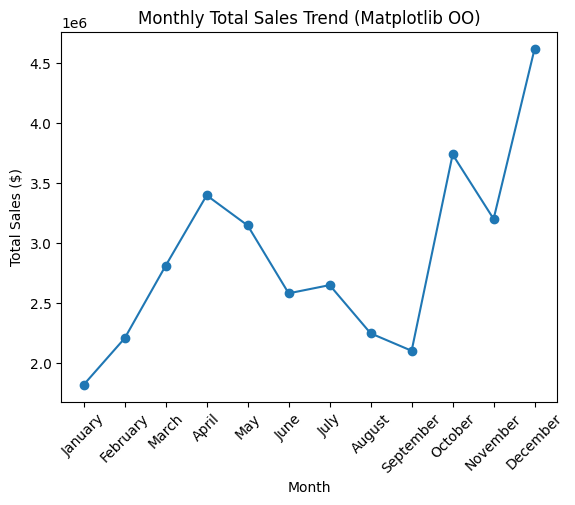

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(
    sales_df["Month"],
    sales_df["Total_Sales"],
    marker="o"
)

ax.set_title("Monthly Total Sales Trend (Matplotlib OO)")
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales ($)")

plt.xticks(rotation=45)
plt.show()


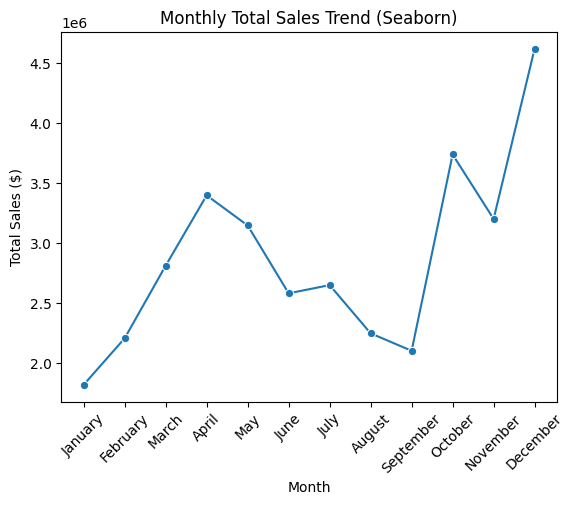

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(
    x="Month",
    y="Total_Sales",
    data=sales_df,
    marker="o"
)

plt.title("Monthly Total Sales Trend (Seaborn)")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.show()


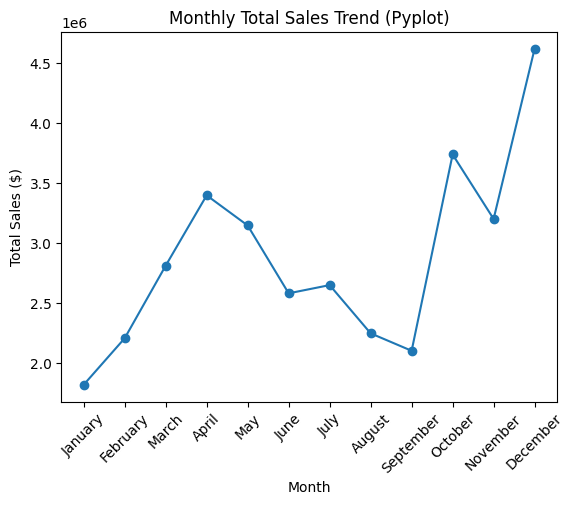

In [4]:
from matplotlib import pyplot as plt

plt.plot(
    sales_df["Month"],
    sales_df["Total_Sales"],
    marker="o"
)

plt.title("Monthly Total Sales Trend (Pyplot)")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.show()


In [5]:
import plotly.express as px

fig = px.line(
    sales_df,
    x="Month",
    y="Total_Sales",
    markers=True,
    title="Monthly Total Sales Trend (Plotly)"
)

fig.show()
